In [43]:
#  Load dataset
# Shape
# Data types
# Missing values
# Duplicates
# Target distribution
# Summary statistics
# Visualisations
# Correlation analysis

In [44]:
import pandas as pd

data = pd.read_csv('../data/cleaned_fraud_dataset.csv')

In [45]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [46]:
data.shape
data.describe()

,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500,0.125100
std,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025,0.330849
min,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000,0.000000
50%,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000,0.000000
75%,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000,0.000000
max,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000,1.000000


In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_amount              10000 non-null  float64
 1   login_attempts                  10000 non-null  int64  
 2   device_risk_score               10000 non-null  float64
 3   transfer_frequency              10000 non-null  int64  
 4   anomaly_score                   10000 non-null  float64
 5   account_age_days                10000 non-null  int64  
 6   transaction_time_hour           10000 non-null  int64  
 7   failed_transactions_last_30d    10000 non-null  int64  
 8   avg_monthly_balance             10000 non-null  float64
 9   daily_transaction_count         10000 non-null  int64  
 10  geo_distance_km                 10000 non-null  int64  
 11  session_duration_minutes        10000 non-null  int64  
 12  transaction_velocity_score      10000 non-nu

EXPLORATORY DATA ANALYSIS

Target Variable Analysis

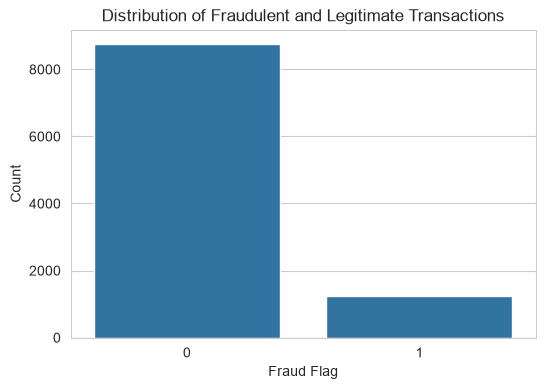

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_flag', data=data)
plt.title('Distribution of Fraudulent and Legitimate Transactions')
plt.xlabel('Fraud Flag')
plt.ylabel('Count')
plt.show()

Numerical Feature Distributions

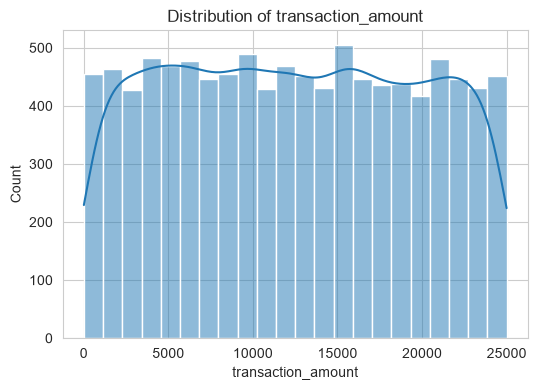

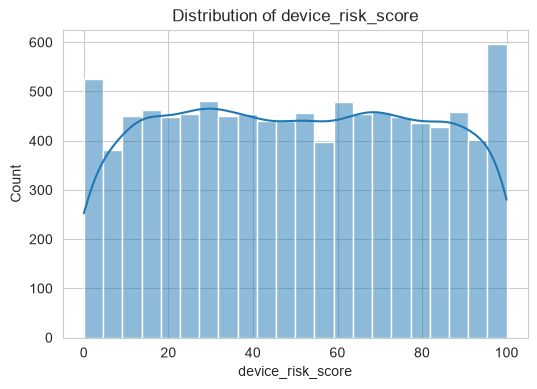

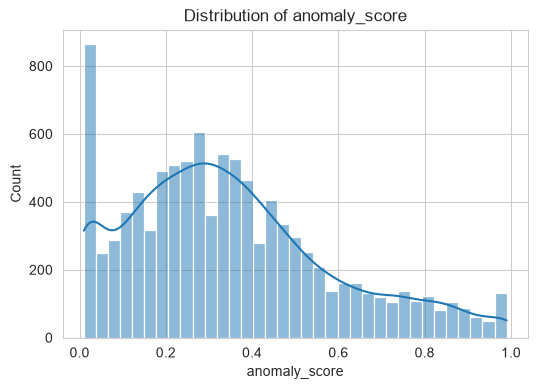

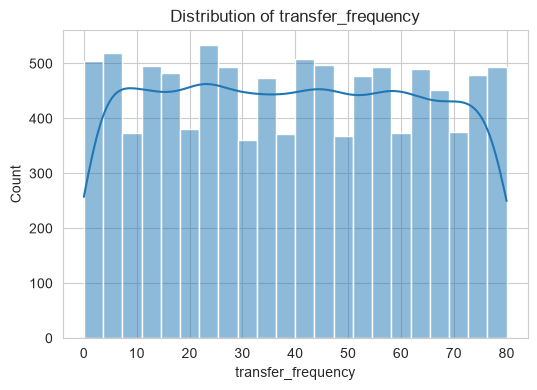

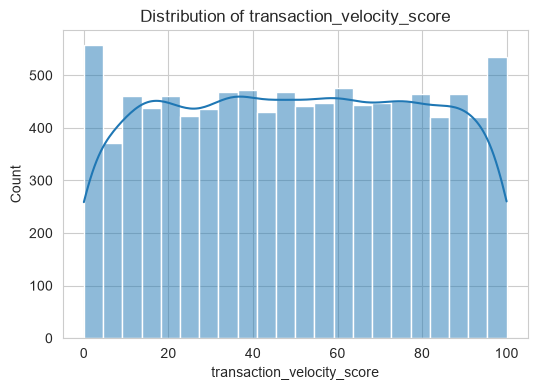

In [49]:
numerical_features = [
    'transaction_amount',
    'device_risk_score',
    'anomaly_score',
    'transfer_frequency',
    'transaction_velocity_score']

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Fraud vs Non-Fraud Comparisons

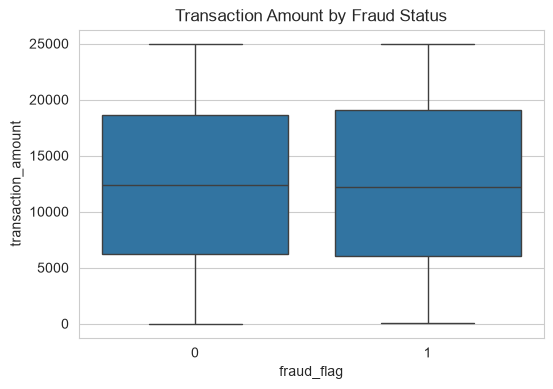

In [50]:
plt.figure(figsize=(6,4))
sns.boxplot(x='fraud_flag', y='transaction_amount', data=data)
plt.title('Transaction Amount by Fraud Status')
plt.show()

Categorical Analysis

In [51]:
pd.crosstab(data['payment_channel'], data['fraud_flag'])

fraud_flag,0,1
payment_channel,,
ATM,676,101
Mobile App,4188,616
POS Terminal,1038,134
Web Banking,2847,400


In [52]:
channel_fraud = pd.crosstab(
    data['payment_channel'],
    data['fraud_flag'],
    normalize='index'
) * 100

print(channel_fraud)

fraud_flag               0          1
payment_channel                      
ATM              87.001287  12.998713
Mobile App       87.177352  12.822648
POS Terminal     88.566553  11.433447
Web Banking      87.680936  12.319064


In [53]:
pd.crosstab(data['authentication_type'], data['fraud_flag'])

fraud_flag,0,1
authentication_type,,
Biometric,1394,191
OTP,3663,551
Password Only,1585,232
Two-Factor Authentication,2107,277


In [54]:
pd.crosstab(data['account_age_days'], data['fraud_flag'])

fraud_flag,0,1
account_age_days,,
6,1,0
7,2,0
8,1,0
9,1,2
10,1,0
...,...,...
4996,3,0
4997,4,1
4998,1,0


In [55]:
##transafer_frequency VS  fraud_flag
pd.crosstab(data[ 'transfer_frequency'], data['fraud_flag'])

fraud_flag,0,1
transfer_frequency,,
0,113,15
1,103,14
2,121,13
3,102,23
4,124,15
...,...,...
76,105,15
77,83,12
78,114,13


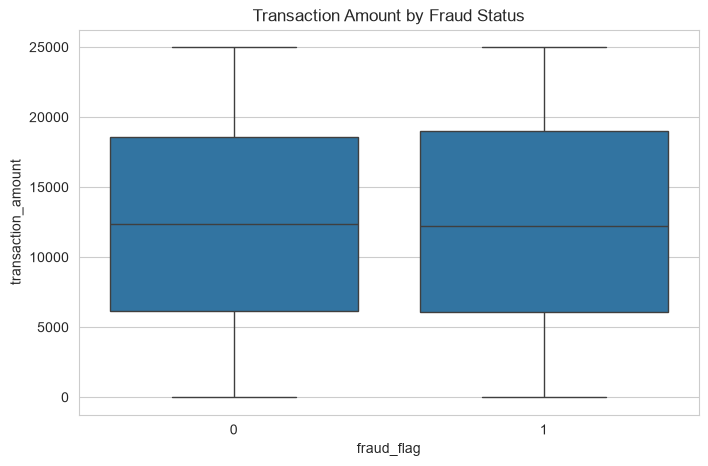

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud_flag', y='transaction_amount', data=data)
plt.title('Transaction Amount by Fraud Status')
plt.show()

In [57]:
data.groupby('fraud_flag')['transaction_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_flag,,,,,,,,
0,8749.0,12398.003867,7183.018614,6.27,6185.36,12356.17,18579.060,24997.52
1,1251.0,12515.910639,7325.254195,30.02,6072.86,12224.55,19034.875,24987.53


In [58]:
data.columns.tolist()

['transaction_amount',
 'login_attempts',
 'device_risk_score',
 'transfer_frequency',
 'anomaly_score',
 'account_age_days',
 'transaction_time_hour',
 'failed_transactions_last_30d',
 'avg_monthly_balance',
 'daily_transaction_count',
 'geo_distance_km',
 'session_duration_minutes',
 'transaction_velocity_score',
 'payment_channel',
 'authentication_type',
 'card_present_flag',
 'international_transaction_flag',
 'suspicious_ip_flag',
 'fraud_flag']

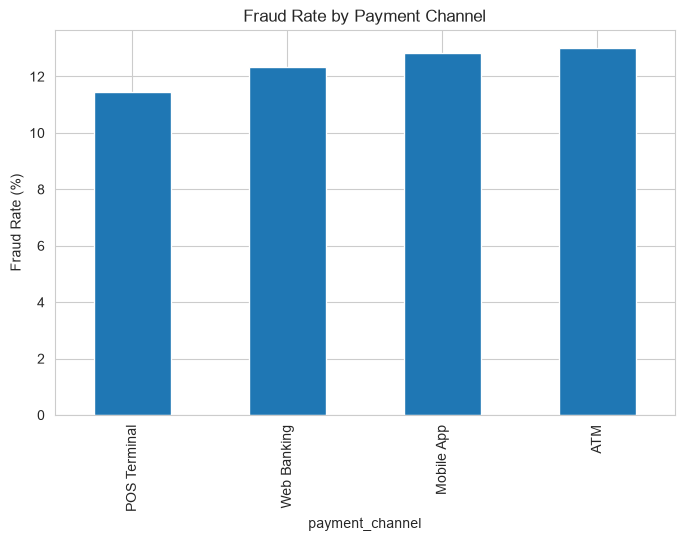

In [59]:
fraud_rate = pd.crosstab(
    data['payment_channel'],
    data['fraud_flag'],
    normalize='index'
)*100

fraud_rate[1].sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Payment Channel')
plt.show()

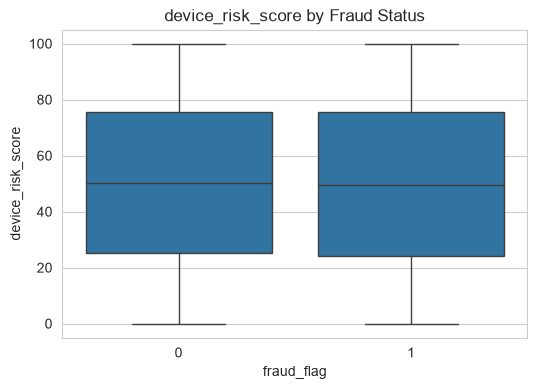

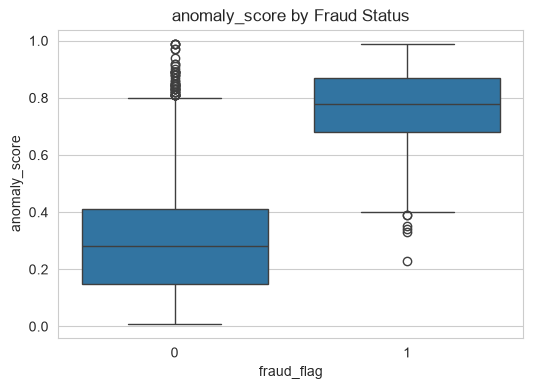

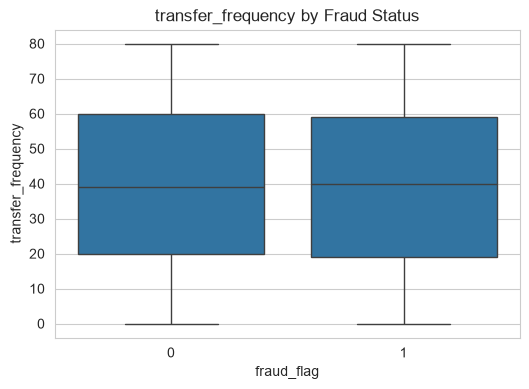

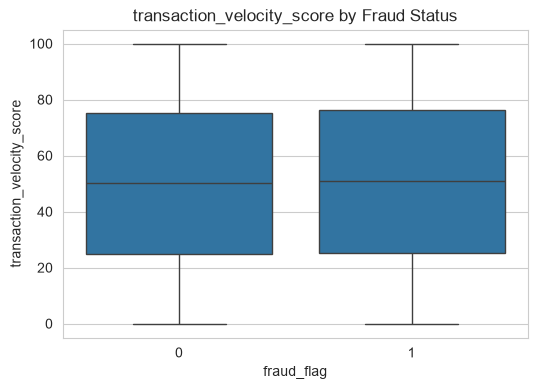

In [60]:
features = [
    'device_risk_score',
    'anomaly_score',
    'transfer_frequency',
    'transaction_velocity_score'
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x='fraud_flag',
        y=col,
        data=data
    )
    plt.title(f'{col} by Fraud Status')
    plt.show()

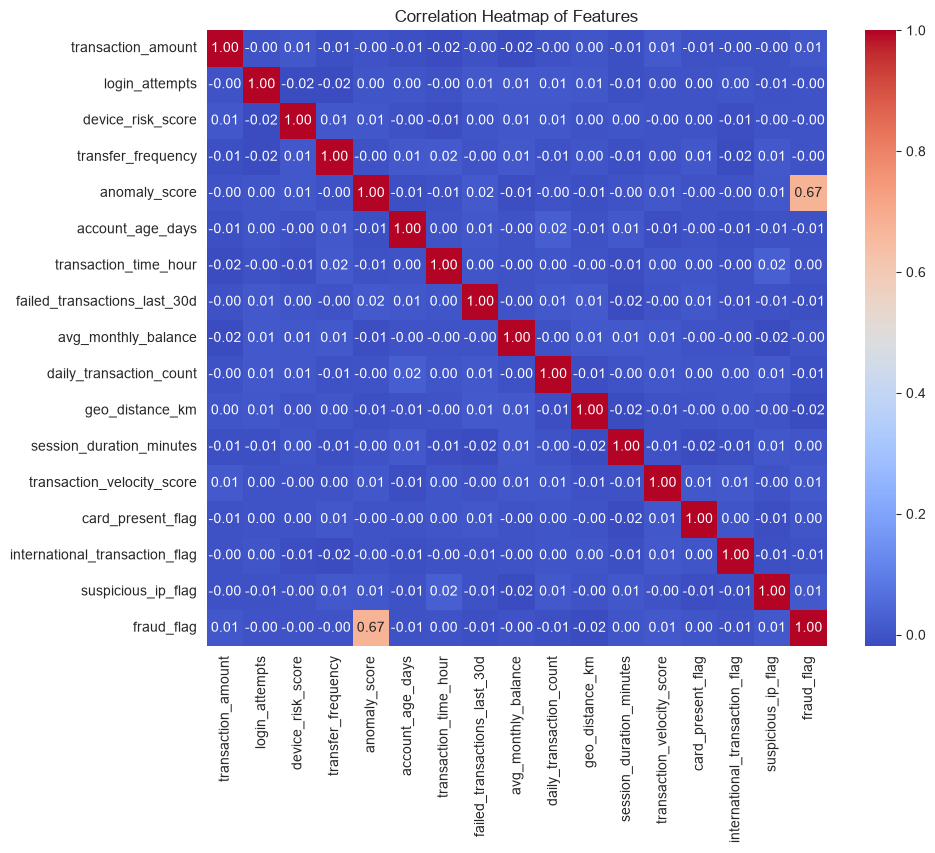

In [61]:
plt.figure(figsize=(10, 8))

corr_matrix = data.select_dtypes(include=[np.number]).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Features')
plt.show()

In [62]:
data.to_csv("../data/eda_completed_dataset.csv",index=False)